# Опорные населенные пункты

In [3]:

import warnings
import sys
import os

import requests
import geopandas as gpd
import pandas as pd
from popframe.models.region import Region
from popframe.method.anchor_settlement import AnchorSettlementBuilder

from typing import Dict, List, Optional, Union
import time

warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')


## Проепроцессинг

### Получение территорий

In [2]:
def fetch_territories(
    url='http://10.32.1.107:5300/api/v1/all_territories',
    parent_id=1,
    get_all_levels=False,
    territory_type_id=None,
    name=None,
    cities_only=False,
    created_at=None,
    centers_only=False
):
    params = {
        'parent_id': parent_id,
        'get_all_levels': get_all_levels,
        'territory_type_id': territory_type_id,
        'name': name,
        'cities_only': cities_only,
        'created_at': created_at,
        'centers_only': centers_only
    }
   
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        geojson_data = response.json()
        return gpd.GeoDataFrame.from_features(geojson_data['features']).set_crs(epsg=4326)
    else:
        print(f"Ошибка запроса: {response.status_code}")
        return None


### Данные по соц категориям

In [3]:
BASE_URL = "http://10.32.1.47:5000/api"
CATEGORIES = ['soc_workers', 'soc_old', 'soc_parents']
METRICS = ['dev', 'soc', 'bas']

def get_region_data(territory_id: int) -> Optional[Dict]:
    try:
        response = requests.get(
            f"{BASE_URL}/regions/values_identities",
            params={'territory_id': int(territory_id)},
            timeout=10
        )
        if response.status_code == 200:
            return response.json()
        return None
    except (requests.exceptions.RequestException, ValueError):
        return None

def fetch_unique_regions_data(territory_ids: List[int]) -> Dict[int, Dict]:
    regions_data = {}
    for territory_id in territory_ids:
        data = get_region_data(territory_id)
        regions_data[territory_id] = data
        time.sleep(0.1)  # Небольшая задержка между запросами
    return regions_data

def enrich_geodataframe(
        gdf: gpd.GeoDataFrame, 
        index: Optional[Union[int, List[int]]] = None,
        suffix_format: str = '_{index}'
    ) -> gpd.GeoDataFrame:

    # Определяем индексы для обработки
    if index is None:
        indices = [0, 1, 2]
    elif isinstance(index, int):
        indices = [index]
    else:
        indices = index

    # Проверяем валидность индексов
    if not all(0 <= i <= 2 for i in indices):
        raise ValueError("Индексы должны быть в диапазоне [0, 2]")

    # Получаем данные для уникальных parent_id
    unique_parents = gdf['parent_id'].unique()
    regions_data = fetch_unique_regions_data(unique_parents[~pd.isna(unique_parents)])

    # Создаем новые колонки для каждой метрики
    for category in CATEGORIES:
        for metric in METRICS:
            for i in indices:
                suffix = suffix_format.format(index=i) if len(indices) > 1 else ''
                column_name = f"{category}_{metric}{suffix}"

                def safe_get_value(parent_id):
                    if pd.isna(parent_id):
                        return None
                    
                    region_data = regions_data.get(parent_id)
                    if region_data is None:
                        return None
                    
                    category_data = region_data.get(category)
                    if category_data is None:
                        return None
                    
                    metric_data = category_data.get(metric)
                    if metric_data is None or i >= len(metric_data):
                        return None
                    
                    return metric_data[i]
                
                gdf[column_name] = gdf['parent_id'].apply(safe_get_value)

    return gdf

def enrich_with_region_data(
        gdf: gpd.GeoDataFrame, 
        index: Optional[Union[int, List[int]]] = None,
        suffix_format: str = '_{index}'
    ) -> gpd.GeoDataFrame:

    enriched_gdf = enrich_geodataframe(gdf, index, suffix_format)

    return enriched_gdf


### Функция поиска родительской территории по типу

In [4]:
# Глобальный словарь для хранения информации о территориях
territory_dict = {}

def initialize_territory_dict(gdf: gpd.GeoDataFrame):
    global territory_dict
    territory_dict = {
        row['id']: {
            'level': row['level'],
            'parent_id': row['parent']['id'] if pd.notna(row['parent']) else None,
            'name': row['name']  # Добавляем name в словарь
        }
        for _, row in gdf.iterrows()
    }

def find_parent_info(id: int, target_type_id: int) -> tuple:
    if id not in territory_dict:
        return None, None

    current = territory_dict[id]
    if not current['parent_id']:
        return None, None

    parent = territory_dict.get(current['parent_id'])
    if parent and parent['level'] == target_type_id:
        return current['parent_id'], parent['name']

    return find_parent_info(current['parent_id'], target_type_id)

def find_parent_ids(target_gdf: gpd.GeoDataFrame, 
                   reference_gdf: gpd.GeoDataFrame, 
                   target_type_id: int) -> gpd.GeoDataFrame:
    # Инициализируем словарь территорий на основе reference_gdf
    initialize_territory_dict(reference_gdf)
    
    # Применяем функцию поиска parent_id и name для каждой территории в target_gdf
    parent_info = target_gdf['id'].apply(
        lambda x: find_parent_info(x, target_type_id)
    )
    
    # Разделяем результаты на два столбца
    target_gdf['parent_id'] = [info[0] if info else None for info in parent_info]
    target_gdf['parent_name'] = [info[1] if info else None for info in parent_info]
    
    return target_gdf

### Получение данных из TownsNet

In [5]:
API_URL = "http://10.32.1.102:5510/provision/{region_id}/get_evaluation"

CATEGORIES_PROV = ["Базовая", "Дополнительная", "Комфорт"]
CATEGORIES_COLUMNS = ['basic', 'additional', 'comfort']

def fetch_gdf(region_id: int, category_name: str, category_column: str):
    params = {"category": category_name}
    
    response = requests.get(API_URL.format(region_id=region_id), params=params)
    if response.status_code == 200:
        data = response.json()
        gdf = gpd.GeoDataFrame.from_features(data["features"])
        gdf = gdf[["geometry", category_column]]
        return gdf
    else:
        raise Exception(f"API request failed with status {response.status_code}")

def fetch_all_categories(region_id: int):
    gdfs = [fetch_gdf(region_id, name, category_column) for name, category_column in zip(CATEGORIES_PROV,CATEGORIES_COLUMNS)]
    
    combined_gdf = gdfs[0]
    
    for gdf, category in zip(gdfs[1:], CATEGORIES_COLUMNS[1:]):
        combined_gdf = combined_gdf.merge(gdf[["geometry", category]], on="geometry", how="outer")
    
    return combined_gdf

In [6]:
def get_population(territories_gdf: gpd.GeoDataFrame):
    POPULATION_COUNT_INDICATOR_ID =1 
    URBAN_API = 'http://10.32.1.107:5300'
    res = requests.get(f'{URBAN_API}/api/v1/indicator/{POPULATION_COUNT_INDICATOR_ID}/values', verify=False)
    res.raise_for_status()
    res_df = pd.DataFrame(res.json())
    
    res_df['territory_id'] = res_df['territory'].apply(lambda x: x['id'] if isinstance(x, dict) else None)
    res_df = res_df[res_df['territory_id'].isin(territories_gdf['id'].values)]
    res_df = (
        res_df
        .groupby('territory_id')
        .agg({'value': 'last'})
        .rename(columns={'value': 'population'})
    )
    
    territories_gdf = territories_gdf.merge(res_df,  left_on='id', right_on='territory_id', how='left')
    territories_gdf['population'] = territories_gdf['population'].fillna(0)  # Заменяем NaN на 0
    
    return territories_gdf

### Получаем данные по городам и ГПСП

In [7]:
all_territories = fetch_territories(parent_id=1, get_all_levels=True, cities_only=False, centers_only=True)
all_territories = all_territories.reset_index().rename(columns={'territory_id': 'id'})
all_territories


,index,geometry,id,territory_type,parent,name,level,properties,admin_center,target_city_type,okato_code,oktmo_code,is_city,created_at,updated_at
0,0,POINT (34.61597 59.54053),2,"{'id': 2, 'name': 'Муниципальное образование'}","{'id': 1, 'name': 'Ленинградская область'}",Бокситогорский муниципальный район,3,"{'Малые города': 2, 'Крупные города': 0, 'Числ...","{'id': 328, 'name': 'город Бокситогорск'}",None,41203000000,41603000,False,2024-06-16T21:35:40.801621Z,2024-11-14T12:17:18.795643Z
1,1,POINT (34.28178 59.4324),3,"{'id': 3, 'name': 'Поселение'}","{'id': 2, 'name': 'Бокситогорский муниципальны...",Самойловское сельское поселение,4,"{'Численность населения': 2154, 'Административ...","{'id': 310, 'name': 'поселок Совхозный'}",None,41203876000,41603476,False,2024-06-16T21:35:40.801621Z,2024-11-14T12:17:52.703740Z
2,2,POINT (33.95669 59.66792),4,"{'id': 3, 'name': 'Поселение'}","{'id': 2, 'name': 'Бокситогорский муниципальны...",Большедворское сельское поселение,4,"{'Численность населения': 1698, 'Административ...","{'id': 427, 'name': 'деревня Большой Двор'}",None,41203812000,41603412,False,2024-06-16T21:35:40.801621Z,2024-11-14T12:17:34.396287Z
3,3,POINT (34.14548 59.52005),5,"{'id': 3, 'name': 'Поселение'}","{'id': 2, 'name': 'Бокситогорский муниципальны...",Пикалевское городское поселение,4,"{'Численность населения': 20169, 'Администрати...","{'id': 335, 'name': 'город Пикалево'}",None,41440000000,41603102,False,2024-06-16T21:35:40.801621Z,2024-11-14T12:17:34.930089Z
4,4,POINT (33.85846 59.34944),6,"{'id': 3, 'name': 'Поселение'}","{'id': 2, 'name': 'Бокситогорский муниципальны...",Борское сельское поселение,4,"{'Численность населения': 3393, 'Административ...","{'id': 2859, 'name': 'деревня Бор'}",None,41203816000,41603416,False,2024-06-16T21:35:40.801621Z,2024-11-14T12:17:35.367513Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3131,3131,POINT (31.2342 59.17022),3133,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 205, 'name': 'Трубникоборское сельское ...",деревня Апраксин Бор,5,{},None,None,41248844010,41648444111,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:24.081332Z
3132,3132,POINT (31.32183 59.18624),3134,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 205, 'name': 'Трубникоборское сельское ...",деревня Александровка,5,{},None,None,41248844002,41648444106,True,2024-06-16T21:35:40.801621Z,2025-05-22T11:14:58.578700Z
3133,3133,POINT (31.48353 59.28739),3135,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 205, 'name': 'Трубникоборское сельское ...",деревня Большая Горка,5,{},None,None,41248860002,41648444131,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:27.219027Z
3134,3134,POINT (31.45352 59.30929),3136,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 205, 'name': 'Трубникоборское сельское ...",деревня Дроздово,5,{},None,None,41248860003,41648444146,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:27.140158Z


In [8]:
# all_territories.to_parquet('data/all_territories.parquet')
# all_territories = gpd.read_parquet('data/all_territories.parquet')

Данные сохранены в файлы, при необходимиости можно раскомментировать код и получить обновленные данные

In [9]:
# Получение данных о городах
towns_gdf = fetch_territories(parent_id=1, get_all_levels=True, cities_only=True, centers_only=True)
towns_gdf

,geometry,territory_id,territory_type,parent,name,level,properties,admin_center,target_city_type,okato_code,oktmo_code,is_city,created_at,updated_at
0,POINT (33.74561 59.36031),207,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 6, 'name': 'Борское сельское поселение'}",деревня Болото,5,{},None,None,41203816004,41603416106,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:49.047689Z
1,POINT (33.78685 59.47791),208,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 6, 'name': 'Борское сельское поселение'}",деревня Большой Остров,5,{},None,None,41203816020,41603416111,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:50.317027Z
2,POINT (33.79438 59.47479),209,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 6, 'name': 'Борское сельское поселение'}",деревня Бор,5,{},None,None,41203816001,41603416101,True,2024-06-16T21:35:40.801621Z,2025-05-22T11:08:10.553286Z
3,POINT (33.77497 59.44313),210,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 6, 'name': 'Борское сельское поселение'}",деревня Бороватое,5,{},None,None,41203816005,41603416116,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:50.270215Z
4,POINT (33.67886 59.33333),211,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 6, 'name': 'Борское сельское поселение'}",деревня Бочево,5,{},None,None,41203816003,41603416121,True,2024-06-16T21:35:40.801621Z,2025-05-22T10:15:56.823065Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,POINT (31.2342 59.17022),3133,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 205, 'name': 'Трубникоборское сельское ...",деревня Апраксин Бор,5,{},None,None,41248844010,41648444111,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:24.081332Z
2927,POINT (31.32183 59.18624),3134,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 205, 'name': 'Трубникоборское сельское ...",деревня Александровка,5,{},None,None,41248844002,41648444106,True,2024-06-16T21:35:40.801621Z,2025-05-22T11:14:58.578700Z
2928,POINT (31.48353 59.28739),3135,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 205, 'name': 'Трубникоборское сельское ...",деревня Большая Горка,5,{},None,None,41248860002,41648444131,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:27.219027Z
2929,POINT (31.45352 59.30929),3136,"{'id': 18, 'name': 'Населенный пункт'}","{'id': 205, 'name': 'Трубникоборское сельское ...",деревня Дроздово,5,{},None,None,41248860003,41648444146,True,2024-06-16T21:35:40.801621Z,2025-05-22T21:46:27.140158Z


In [10]:
towns_gdf['is_anchor_settlement'] = towns_gdf['target_city_type'].apply(lambda x: x is not None and 'id' in x)
towns_gdf["is_anchor_settlement"] = towns_gdf["is_anchor_settlement"].astype(bool)
towns_gdf = towns_gdf[['geometry', 'territory_id', 'name', 'is_anchor_settlement']]
towns_gdf = towns_gdf.reset_index().rename(columns={'territory_id': 'id'})
towns_gdf

,index,geometry,id,name,is_anchor_settlement
0,0,POINT (33.74561 59.36031),207,деревня Болото,False
1,1,POINT (33.78685 59.47791),208,деревня Большой Остров,False
2,2,POINT (33.79438 59.47479),209,деревня Бор,False
3,3,POINT (33.77497 59.44313),210,деревня Бороватое,False
4,4,POINT (33.67886 59.33333),211,деревня Бочево,False
...,...,...,...,...,...
2926,2926,POINT (31.2342 59.17022),3133,деревня Апраксин Бор,False
2927,2927,POINT (31.32183 59.18624),3134,деревня Александровка,False
2928,2928,POINT (31.48353 59.28739),3135,деревня Большая Горка,False
2929,2929,POINT (31.45352 59.30929),3136,деревня Дроздово,False


In [11]:
towns_gdf = find_parent_ids(towns_gdf, all_territories, target_type_id=4)
towns_gdf

,index,geometry,id,name,is_anchor_settlement,parent_id,parent_name
0,0,POINT (33.74561 59.36031),207,деревня Болото,False,6.0,Борское сельское поселение
1,1,POINT (33.78685 59.47791),208,деревня Большой Остров,False,6.0,Борское сельское поселение
2,2,POINT (33.79438 59.47479),209,деревня Бор,False,6.0,Борское сельское поселение
3,3,POINT (33.77497 59.44313),210,деревня Бороватое,False,6.0,Борское сельское поселение
4,4,POINT (33.67886 59.33333),211,деревня Бочево,False,6.0,Борское сельское поселение
...,...,...,...,...,...,...,...
2926,2926,POINT (31.2342 59.17022),3133,деревня Апраксин Бор,False,205.0,Трубникоборское сельское поселение
2927,2927,POINT (31.32183 59.18624),3134,деревня Александровка,False,205.0,Трубникоборское сельское поселение
2928,2928,POINT (31.48353 59.28739),3135,деревня Большая Горка,False,205.0,Трубникоборское сельское поселение
2929,2929,POINT (31.45352 59.30929),3136,деревня Дроздово,False,205.0,Трубникоборское сельское поселение


In [13]:
towns_gdf = enrich_with_region_data(towns_gdf, index=0)
towns_gdf

,index,geometry,id,name,is_anchor_settlement,parent_id,parent_name,population,soc_workers_dev,soc_workers_soc,soc_workers_bas,soc_old_dev,soc_old_soc,soc_old_bas,soc_parents_dev,soc_parents_soc,soc_parents_bas
0,0,POINT (33.74561 59.36031),207,деревня Болото,False,6.0,Борское сельское поселение,10.0,None,0.033795,0.096542,0.194644,0.041469,0.072120,0.308008,0.033795,0.002834
1,1,POINT (33.78685 59.47791),208,деревня Большой Остров,False,6.0,Борское сельское поселение,68.0,None,0.033795,0.096542,0.194644,0.041469,0.072120,0.308008,0.033795,0.002834
2,2,POINT (33.79438 59.47479),209,деревня Бор,False,6.0,Борское сельское поселение,1734.0,None,0.033795,0.096542,0.194644,0.041469,0.072120,0.308008,0.033795,0.002834
3,3,POINT (33.77497 59.44313),210,деревня Бороватое,False,6.0,Борское сельское поселение,10.0,None,0.033795,0.096542,0.194644,0.041469,0.072120,0.308008,0.033795,0.002834
4,4,POINT (33.67886 59.33333),211,деревня Бочево,False,6.0,Борское сельское поселение,10.0,None,0.033795,0.096542,0.194644,0.041469,0.072120,0.308008,0.033795,0.002834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,2926,POINT (31.2342 59.17022),3133,деревня Апраксин Бор,False,205.0,Трубникоборское сельское поселение,313.0,None,0.152398,0.520615,0.271781,0.105424,0.491682,0.335392,0.152398,0.226743
2927,2927,POINT (31.32183 59.18624),3134,деревня Александровка,False,205.0,Трубникоборское сельское поселение,313.0,None,0.152398,0.520615,0.271781,0.105424,0.491682,0.335392,0.152398,0.226743
2928,2928,POINT (31.48353 59.28739),3135,деревня Большая Горка,False,205.0,Трубникоборское сельское поселение,313.0,None,0.152398,0.520615,0.271781,0.105424,0.491682,0.335392,0.152398,0.226743
2929,2929,POINT (31.45352 59.30929),3136,деревня Дроздово,False,205.0,Трубникоборское сельское поселение,5.0,None,0.152398,0.520615,0.271781,0.105424,0.491682,0.335392,0.152398,0.226743


In [14]:
provision_gdf = fetch_all_categories(1)
provision_gdf = provision_gdf.set_crs(epsg=4326)

# Добавляем буфер вокруг точек в gdf1
orig_geometry = towns_gdf['geometry']
towns_gdf['geometry'] = towns_gdf.geometry.buffer(0.002)
towns_gdf = towns_gdf.sjoin(provision_gdf, how='left', predicate='intersects')
towns_gdf['geometry'] = orig_geometry
towns_gdf['provision'] = towns_gdf[['basic', 'additional', 'comfort']].mean(axis=1)
# towns_gdf.to_parquet('data/towns_gdf.parquet')
towns_gdf

,index,geometry,id,name,is_anchor_settlement,parent_id,parent_name,population,soc_workers_dev,soc_workers_soc,...,soc_old_soc,soc_old_bas,soc_parents_dev,soc_parents_soc,soc_parents_bas,index_right,basic,additional,comfort,provision
0,0,POINT (33.74561 59.36031),207,деревня Болото,False,6.0,Борское сельское поселение,10.0,None,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,NaN,NaN,NaN,NaN,NaN
1,1,POINT (33.78685 59.47791),208,деревня Большой Остров,False,6.0,Борское сельское поселение,68.0,None,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,NaN,NaN,NaN,NaN,NaN
2,2,POINT (33.79438 59.47479),209,деревня Бор,False,6.0,Борское сельское поселение,1734.0,None,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,NaN,NaN,NaN,NaN,NaN
3,3,POINT (33.77497 59.44313),210,деревня Бороватое,False,6.0,Борское сельское поселение,10.0,None,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,3.0,0.53,0.7,0.4,0.543333
4,4,POINT (33.67886 59.33333),211,деревня Бочево,False,6.0,Борское сельское поселение,10.0,None,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,2926,POINT (31.2342 59.17022),3133,деревня Апраксин Бор,False,205.0,Трубникоборское сельское поселение,313.0,None,0.152398,...,0.105424,0.491682,0.335392,0.152398,0.226743,2926.0,0.20,0.4,0.2,0.266667
2927,2927,POINT (31.32183 59.18624),3134,деревня Александровка,False,205.0,Трубникоборское сельское поселение,313.0,None,0.152398,...,0.105424,0.491682,0.335392,0.152398,0.226743,NaN,NaN,NaN,NaN,NaN
2928,2928,POINT (31.48353 59.28739),3135,деревня Большая Горка,False,205.0,Трубникоборское сельское поселение,313.0,None,0.152398,...,0.105424,0.491682,0.335392,0.152398,0.226743,NaN,NaN,NaN,NaN,NaN
2929,2929,POINT (31.45352 59.30929),3136,деревня Дроздово,False,205.0,Трубникоборское сельское поселение,5.0,None,0.152398,...,0.105424,0.491682,0.335392,0.152398,0.226743,NaN,NaN,NaN,NaN,NaN


In [15]:
# towns_gdf = gpd.read_parquet('data/cities_gdf.parquet')
# towns_gdf['provision'] = towns_gdf[['basic', 'additional', 'comfort']].mean(axis=1)
towns_gdf = towns_gdf.set_index("id", drop=False)
towns_gdf = towns_gdf.fillna(0)
towns_gdf = towns_gdf.to_crs(4326)
towns_gdf['parent_name'] = towns_gdf['parent_name'].fillna('').astype(str)

# теперь можно безопасно сохранить в parquet
towns_gdf.to_parquet('data/towns_gdf.parquet')
towns_gdf

,index,geometry,id,name,is_anchor_settlement,parent_id,parent_name,population,soc_workers_dev,soc_workers_soc,...,soc_old_soc,soc_old_bas,soc_parents_dev,soc_parents_soc,soc_parents_bas,index_right,basic,additional,comfort,provision
id,,,,,,,,,,,,,,,,,,,,,
207,0,POINT (33.74561 59.36031),207,деревня Болото,False,6.0,Борское сельское поселение,10.0,0,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,0.0,0.00,0.0,0.0,0.000000
208,1,POINT (33.78685 59.47791),208,деревня Большой Остров,False,6.0,Борское сельское поселение,68.0,0,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,0.0,0.00,0.0,0.0,0.000000
209,2,POINT (33.79438 59.47479),209,деревня Бор,False,6.0,Борское сельское поселение,1734.0,0,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,0.0,0.00,0.0,0.0,0.000000
210,3,POINT (33.77497 59.44313),210,деревня Бороватое,False,6.0,Борское сельское поселение,10.0,0,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,3.0,0.53,0.7,0.4,0.543333
211,4,POINT (33.67886 59.33333),211,деревня Бочево,False,6.0,Борское сельское поселение,10.0,0,0.033795,...,0.041469,0.072120,0.308008,0.033795,0.002834,0.0,0.00,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3133,2926,POINT (31.2342 59.17022),3133,деревня Апраксин Бор,False,205.0,Трубникоборское сельское поселение,313.0,0,0.152398,...,0.105424,0.491682,0.335392,0.152398,0.226743,2926.0,0.20,0.4,0.2,0.266667
3134,2927,POINT (31.32183 59.18624),3134,деревня Александровка,False,205.0,Трубникоборское сельское поселение,313.0,0,0.152398,...,0.105424,0.491682,0.335392,0.152398,0.226743,0.0,0.00,0.0,0.0,0.000000
3135,2928,POINT (31.48353 59.28739),3135,деревня Большая Горка,False,205.0,Трубникоборское сельское поселение,313.0,0,0.152398,...,0.105424,0.491682,0.335392,0.152398,0.226743,0.0,0.00,0.0,0.0,0.000000


## Работа метода

### Границы опорных пунктов

In [4]:
from popframe.models.region import Region
from popframe.method.anchor_settlement import AnchorSettlementBuilder

# Создаем экземпляр класса
region_model = Region.from_pickle('data/1.pickle')
builder = AnchorSettlementBuilder(region=region_model)

# Вызываем метод построения границ
towns_gdf = gpd.read_parquet('data/towns_gdf.parquet')
settlement_boundaries = builder.get_anchor_settlement_boundaries(towns_gdf, time = 50)

In [ ]:
# settlement_boundaries.to_file('data/settlement_boundaries.geojson', driver='GeoJSON')

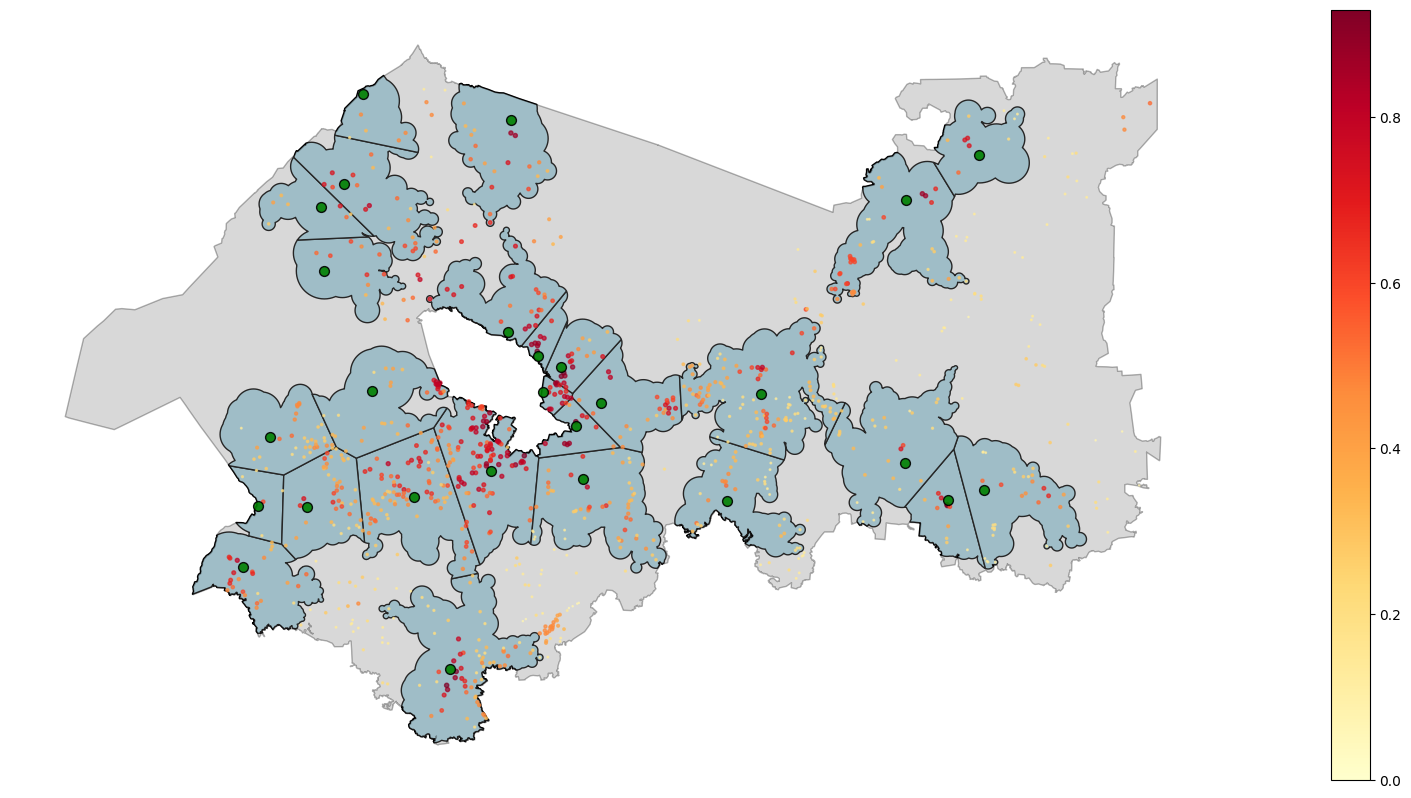

In [5]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Создание графика и оси
fig, ax = plt.subplots(figsize=(30, 10))

# Визуализация границ с заливкой светло-голубым цветом
settlement_boundaries.plot(ax=ax, edgecolor="black", facecolor="#ADD8E6", linewidth=1)

# Визуализация границ региона (серым цветом с прозрачностью)
region_boundary = region_model.region
region_boundary.plot(ax=ax, color='gray', edgecolor='black', alpha=0.3)

local_crs = region_boundary.crs

        
non_anchor_towns = towns_gdf[towns_gdf["is_anchor_settlement"] == False]  # Не опорные города
anchor_towns = towns_gdf[towns_gdf["is_anchor_settlement"] == True]  # Не опорные города

non_anchor_towns = non_anchor_towns.to_crs(local_crs)
anchor_towns = anchor_towns.to_crs(local_crs)

# Визуализация не опорных городов (тепловая карта по provision)
non_anchor_towns.plot(
    ax=ax, 
    column="basic",  # Градиент по 'provision'
    cmap="YlOrRd",  # От жёлтого к красному
    legend=True,  # Включаем легенду
    markersize=non_anchor_towns["basic"] * 10,  # Размер точек по значению
    alpha=0.7
)

# Визуализация опорных городов (зелёным цветом)
anchor_towns.plot(
    ax=ax,
    color="green",  # Фиксированный зелёный цвет
    markersize=50,  # Размер маркеров
    alpha=0.9,
    edgecolor="black"
)


# Настройки отображения
ax.set_axis_off()

# Показ графика
plt.show()
